ANALISI ESPLORATIVA DEI DATI

Caricamento e osservazione del dataset: Abbiamo usato .parquet invece che .csv perchè -parquet è più veloce e compresso e permette la gestione di grandi dataset. quando il dataset contiene colonne con tipi avanzati di pandas, fastparquet è più stabile per leggere i file Parquet in Jupyter. Ergo abbiamo usato fastparquet

dawjdbadkjb
da


Aggiunta per provare git da vscodeCIAOOOdadwija


In [14]:
import pandas as pd

# Percorso del file Parquet
file_path = r"C:\Users\ruben\Desktop\Progetto Data&Web\data\github_issues_dataset.parquet"

# Leggere il file
df = pd.read_parquet(file_path, engine='fastparquet')

# Visualizzare le prime righe del dataset
df.head()

,id,repo,title,body,labels,priority,severity
0,393061,youtube-dl,Output file size with -s or -g,Was: http://bitbucket.org/rg3/youtube-dl/issue...,request,medium,Critical
1,1637737,youtube-dl,Create a php API and demo page,youtube-dl is often embedded by php applicatio...,php,low,Major
2,1639054,youtube-dl,"integrate template ""special sequences"" in help...",like in http://rg3.github.com/youtube-dl/docum...,request,low,Minor
3,1789251,youtube-dl,Add a path option to --keep-video,"Hey there,\n\nI think it would be a great idea...",request,low,Minor
4,1789512,youtube-dl,add support for picasaweb.google.com video clips,> /opt/local/bin/youtube-dl -t https://picasaw...,site-support-request,low,Minor


Controllo tipi di dati e i valori mancanti

In [15]:
# Visualizzare i tipi di dati
print("Tipi di dati per colonna:")
print(df.dtypes)

# Contare i valori mancanti per colonna
print("\nValori mancanti per colonna:")
print(df.isnull().sum())

Tipi di dati per colonna:
id           int64
repo        object
title       object
body        object
labels      object
priority    object
severity    object
dtype: object

Valori mancanti per colonna:
id            0
repo          0
title         0
body        133
labels        0
priority      0
severity      0
dtype: int64


Il dataset è quasi completo.
L’unica colonna con valori mancanti è body, che ha 133 celle vuote su tutte le righe.
Questo significa che alcune issue non hanno una descrizione testuale.

#PULIZIA DEL DATASET

Pulizia del dataset:Eliminazione delle colonne con feature non rilevanti per il nostro scopo (Id, repo, priority, severity). 
Non eliminiamo i valori vuoti del body perchè nel mondo reale ci saranno issue senza descrizione, e il modello deve saper gestire quei casi. 

In [16]:
df = df[['title', 'body', 'labels']].copy()
print(df.shape)
df.head()

(114073, 3)


,title,body,labels
0,Output file size with -s or -g,Was: http://bitbucket.org/rg3/youtube-dl/issue...,request
1,Create a php API and demo page,youtube-dl is often embedded by php applicatio...,php
2,"integrate template ""special sequences"" in help...",like in http://rg3.github.com/youtube-dl/docum...,request
3,Add a path option to --keep-video,"Hey there,\n\nI think it would be a great idea...",request
4,add support for picasaweb.google.com video clips,> /opt/local/bin/youtube-dl -t https://picasaw...,site-support-request


CONTROLLO COLONNA LABELS PRIMA DI FARE MAPPING PERCHè VOGLIAMO VEDERE IL FORMAT(STRING/LISTE) E CAPIRE COME CALOVARE

In [17]:
# vedi i primi 20 valori unici per capire il formato
print(df['labels'].value_counts().head(20))

labels
bug                                    2380
NeedsInvestigation                     1869
Suggestion,Awaiting More Feedback      1195
bug-report                             1137
enhancement                            1072
Needs-Triage                            940
site-support-request                    691
Issue-Bug,Needs-Triage                  636
Bug                                     613
oncall: jit                             607
needs triage,issue: bug report          557
A-diagnostics,T-compiler                543
Proposal                                518
feature request                         511
NeedsInvestigation,compiler/runtime     478
bug,topic:editor                        455
request                                 420
Suggestion,In Discussion                406
bug,needs triage                        398
Needs Investigation                     371
Name: count, dtype: int64


Mappo tutte le possibili labels in 3 GRANDI classi

In [18]:
def map_label(label_str):
    label_str = str(label_str).lower()
    if 'bug' in label_str:
        return 'bug'
    elif 'enhancement' in label_str or 'feature' in label_str or 'request' in label_str:
        return 'feature'
    elif 'question' in label_str or 'help' in label_str:
        return 'question'
    else:
        return None  # issue con label non classificabile

df['label'] = df['labels'].apply(map_label)

# rimuovi le righe senza label chiara
df = df.dropna(subset=['label'])
print(df.shape)
print(df['label'].value_counts())

(59826, 4)
label
bug         34048
feature     23322
question     2456
Name: count, dtype: int64


Creiamo la colonna testo unificata 

In [19]:
# riempi i body nulli con stringa vuota prima di concatenare
df['body'] = df['body'].fillna('')
df['text'] = df['title'] + ' ' + df['body']

# rimuovi righe con testo troppo corto (meno di 3 parole)
df = df[df['text'].str.split().str.len() >= 3]
print(df.shape)

(59823, 5)


Distribuzione delle classi(Primo Grafico)

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['steelblue', 'coral', 'mediumseagreen'])
plt.title('Distribuzione delle classi')
plt.xlabel('Classe')
plt.ylabel('Numero di issue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/class_distribution.png')
plt.show()

Lunghezza media dei testi per classi

            count        mean         std  min    25%    50%     75%      max
label                                                                        
bug       34046.0  279.834019  406.290415  3.0  122.0  197.0  309.00  26381.0
feature   23321.0  193.011320  281.541704  3.0   77.0  136.0  234.00  18485.0
question   2456.0  246.305782  360.865417  6.0   91.0  171.5  278.25   7185.0


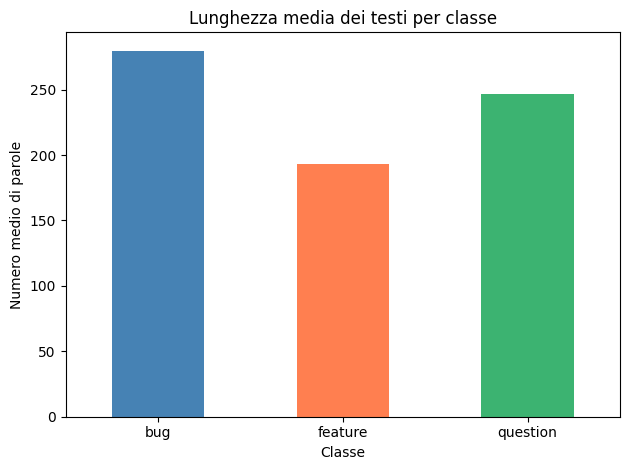

In [21]:
df['num_words'] = df['text'].str.split().str.len()

print(df.groupby('label')['num_words'].describe())

df.groupby('label')['num_words'].mean().plot(kind='bar', color=['steelblue', 'coral', 'mediumseagreen'])
plt.title('Lunghezza media dei testi per classe')
plt.xlabel('Classe')
plt.ylabel('Numero medio di parole')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/text_length.png')
plt.show()

Salviamo il Dataset pulito


In [22]:
df_clean = df[['text', 'label']].copy()
df_clean.to_csv('../data/github_issues_clean.csv', index=False)
print("Dataset pulito salvato.")
print(df_clean.shape)
df_clean.head()

Dataset pulito salvato.
(59823, 2)


,text,label
0,Output file size with -s or -g Was: http://bit...,feature
2,"integrate template ""special sequences"" in help...",feature
3,"Add a path option to --keep-video Hey there,\n...",feature
4,add support for picasaweb.google.com video cli...,feature
5,Add debug representation of trait objects ### ...,bug
